# 01 — Evaluation rigor: measuring a high-variance agent honestly

Poker (like a trading backtest) is *high variance*: a few unlucky deals can swamp a real edge. This notebook reproduces — straight from the committed `results/*.json`, **no retraining** — how this project decides whether an edge is real:

1. **Paired seeds + bootstrap CIs + an exact binomial sign test** on the headline RL-vs-myopic match (the matches are binary bust outcomes, so the sign test is the right test; the paired t-test only corroborates).
2. **Variance reduction** (duplicate/mirror matching and an all-in-EV control variate, the DIVAT/AIVAT family — `references.md` §2).
3. The honest verdict: *one edge resolves over the baseline at 200 paired seeds, the rest stay marginal* — and rigor, not a single headline number, is the deliverable.


In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. The headline edge, recomputed from per-seed PnL

`results/headline_history.json` stores the per-seed chip differences of the final RL agent vs the myopic EV baseline. We re-run the project's own `bootstrap_ci`, the **exact binomial sign test** (the right test — the matches are binary bust outcomes, so only the *sign* of each per-seed diff is informative), and a `paired_t_test` on that raw vector — the printed CI should match the committed one exactly (that is the reproduction).

In [2]:
from src.stats import bootstrap_ci, paired_t_test, binomial_sign_test
h = load("headline_history.json")["final"]
diffs = h["per_seed_diffs"]
ci = bootstrap_ci(diffs)
b = binomial_sign_test(diffs)   # the right test: matches are binary bust outcomes
t = paired_t_test(diffs)        # treats the +/-2000 spread as continuous; corroborates
print(f"matches: {b['wins']}/{h['n_seeds']}  "
      f"mean chip diff = {ci['mean']:+.1f}")
print(f"95% bootstrap CI = [{ci['lo']:+.0f}, {ci['hi']:+.0f}]  "
      f"(committed: [{h['ci95']['lo']:+.0f}, {h['ci95']['hi']:+.0f}])")
print(f"exact binomial sign test p = {b['p_value']:.4f}   "
      f"(paired t agrees, p = {t['p_value']:.4f})")
print()
resolved = ci["lo"] > 0 or ci["hi"] < 0
verdict = ("EXCLUDES 0 — a resolved edge over the baseline (the ~63% win rate is\n"
           "stable across samples; 50 seeds lacked the power to resolve it, 200 do)"
           if resolved else
           "straddles 0 — a real but MARGINAL edge, not a decisive win")
print(f"Read it honestly: the mean is positive and the 95% CI {verdict}.")
print("Still modest: a 0-parameter Kelly bot beats this RL agent head-to-head.")

matches: 125/200  mean chip diff = +500.0
95% bootstrap CI = [+240, +760]  (committed: [+240, +760])
exact binomial sign test p = 0.0005   (paired t agrees, p = 0.0003)

Read it honestly: the mean is positive and the 95% CI EXCLUDES 0 — a resolved edge over the baseline (the ~63% win rate is
stable across samples; 50 seeds lacked the power to resolve it, 200 do).
Still modest: a 0-parameter Kelly bot beats this RL agent head-to-head.


## 2. Variance reduction — the same edge, measured four ways

`results/variance_reduction.json` measures one fixed edge (Myopic vs Aggro, 120 paired seeds) four ways. Duplicate/**mirror matching** (same deck, swapped seats) cancels seat/deck luck and narrows the CI; the all-in-EV control variate is ~neutral in this *bust-match* format (its big gains are for per-hand win-rate estimation).

In [3]:
vr = load("variance_reduction.json")
print(f"{'arm':14s} {'mean':>8s} {'CI width':>10s} {'% of raw':>9s}")
for a in vr["arms"]:
    print(f"{a['arm']:14s} {a['mean']:+8.1f} {a['ci_width']:10.0f} "
          f"{a['ci_width_vs_raw']:8.0%}")

arm                mean   CI width  % of raw
raw               +33.3        712     100%
mirror            +56.8        464      65%
luck_adjusted     +42.6        704      99%
mirror+luck       +63.1        458      64%


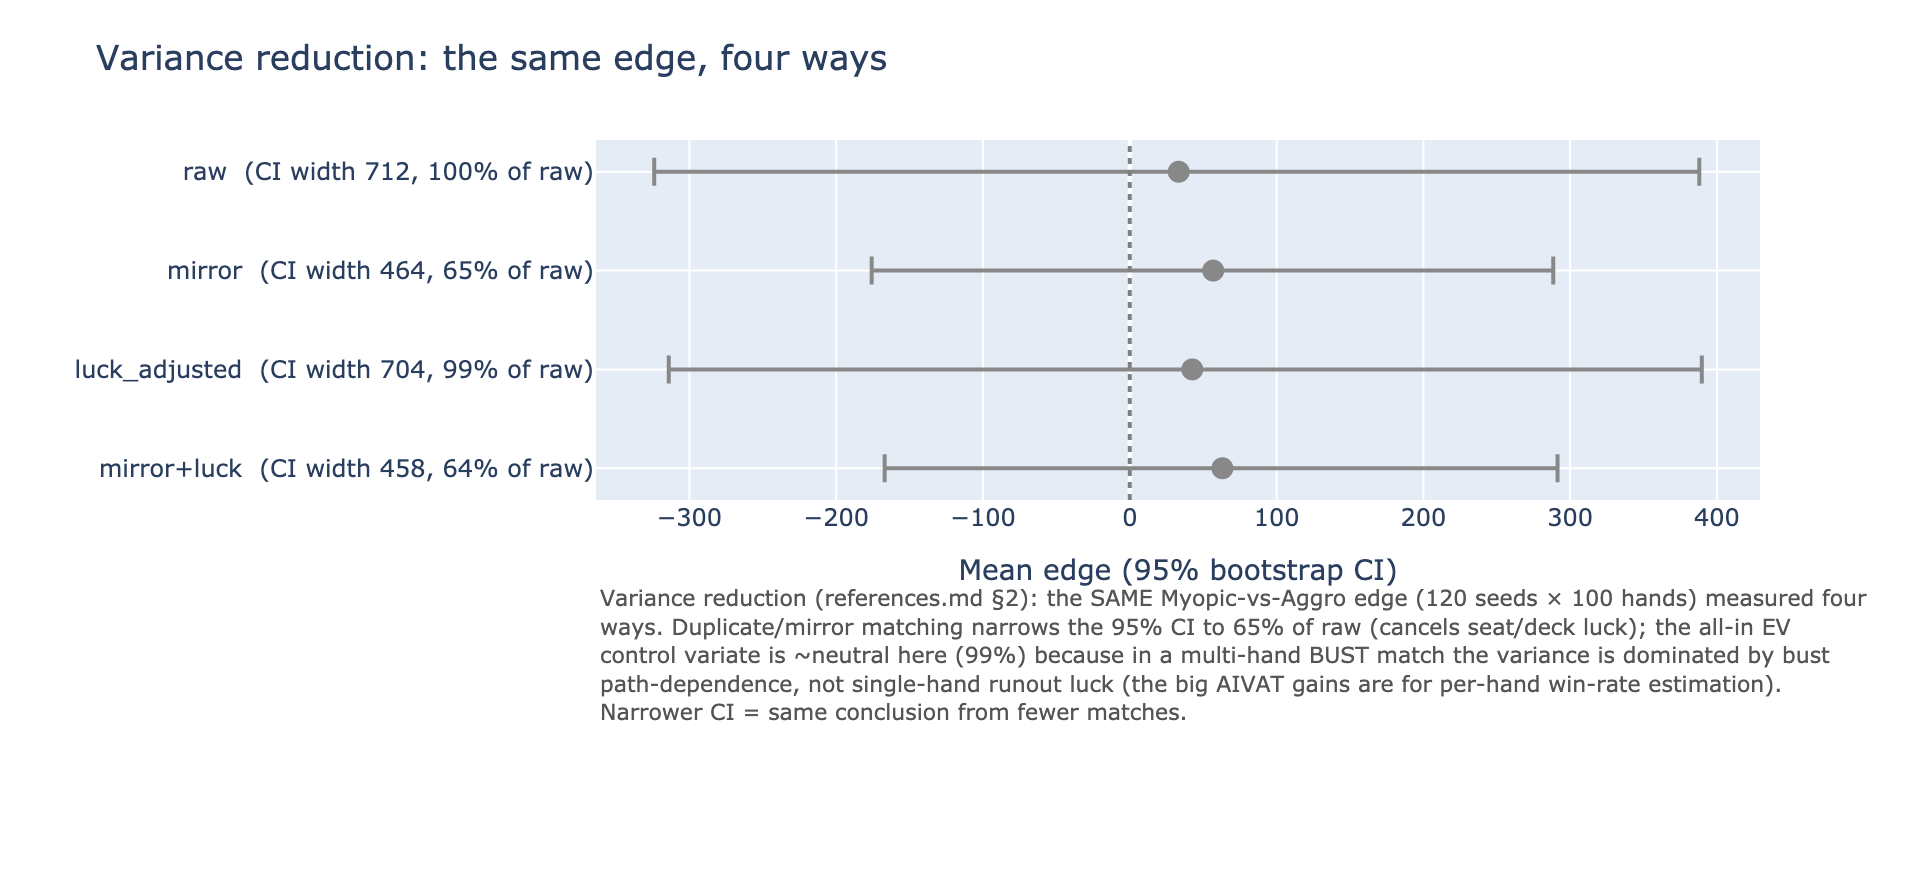

In [4]:
fig("variance_reduction.png")

## 3. Are *any* of the headline edges real?

The executive summary puts every claimed edge on one axis with its 95% bootstrap CI. Gray = the CI straddles 0 (within per-seed noise).

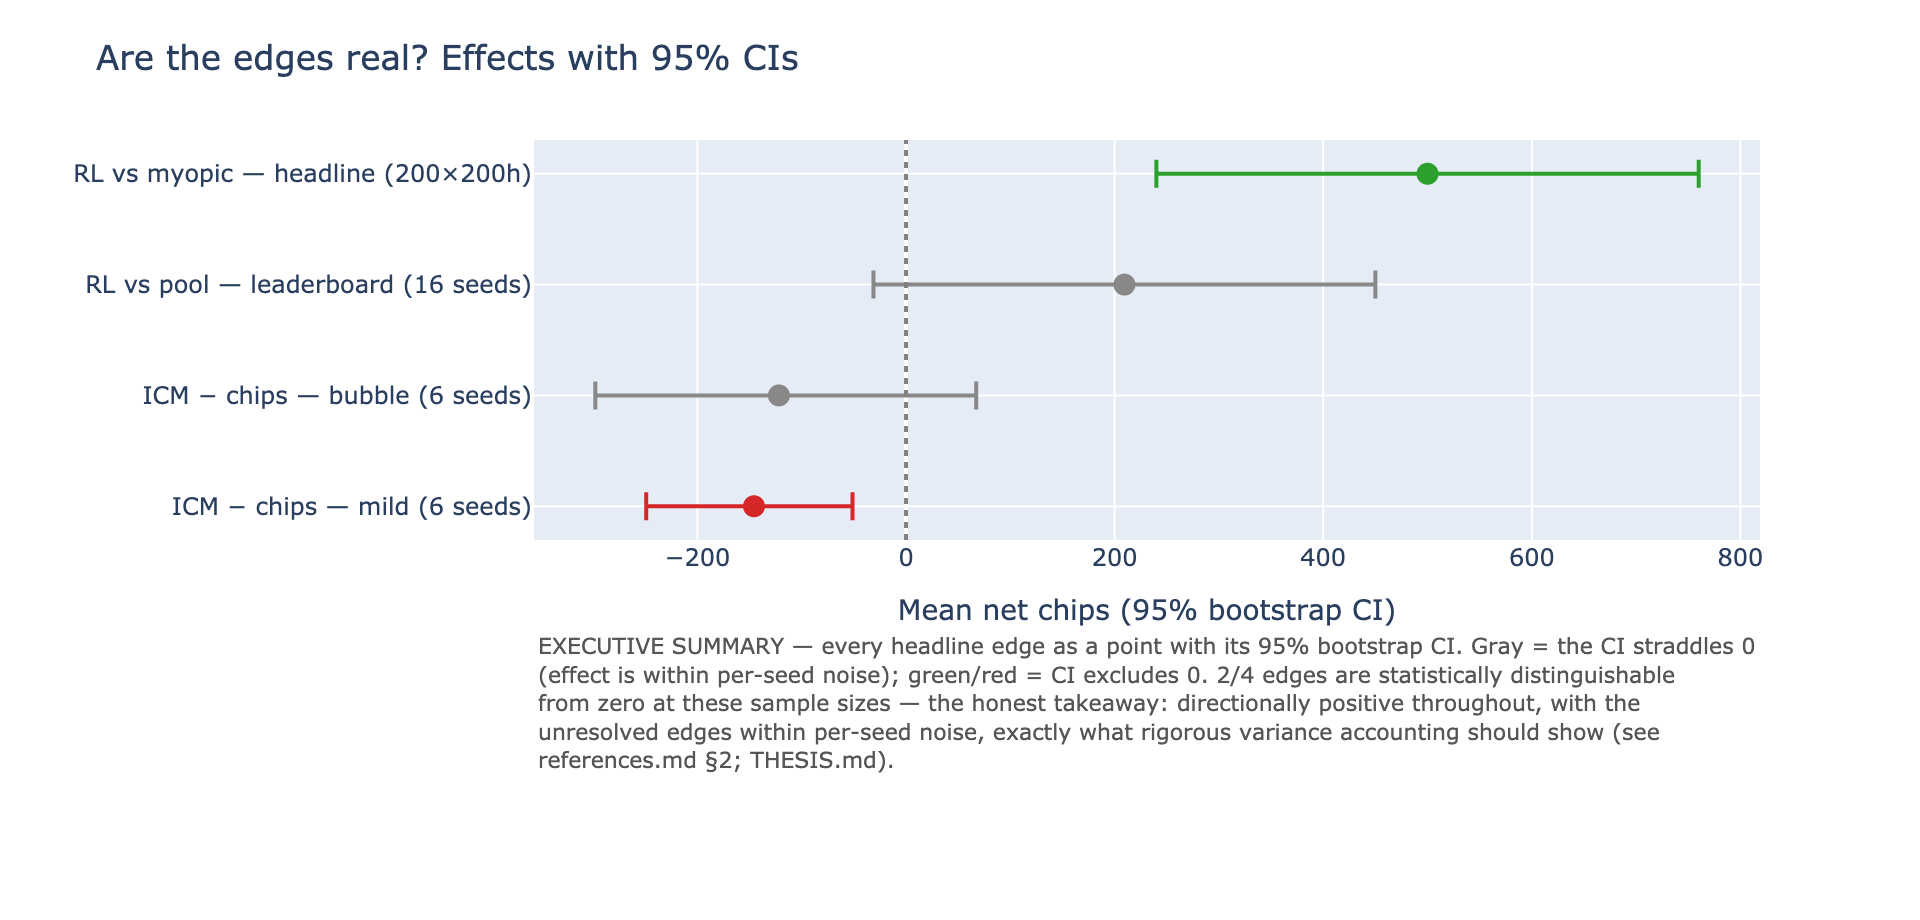

In [5]:
fig("exec_summary.png")

### Honest takeaway

The RL agent's edge over the myopic baseline **resolves** at 200 paired seeds (exact binomial p=0.0005, 95% CI excludes 0); the remaining edges (opponent pool, ICM/Kelly risk-aversion) stay marginal or directionally negative at these sample sizes — and a 0-parameter Kelly bot still beats the RL agent head-to-head (5-11). That mix — one resolved edge, honest nulls elsewhere — is the correct finding for a single-developer DQN in a high-variance game. The transferable artifact is the **measurement discipline** — paired design, bootstrap CIs, the *right* significance test, variance reduction — not a single headline number. See `THESIS.md` and `references.md` §2.